# IndiGo Passenger Sheet — 6-Model Benchmark
Same workflow as the Company notebook:
1. Mount Drive & install deps
2. Majority-vote across 3 coders → Final_Label
3. Audit codebook (per-code counts) & drop ultra-rare codes (<3 samples)
4. Preprocess & binarise (multi-label)
5. Run 6 models: 3 ML (LogReg, SVM, Voting) + 2 DL (BiLSTM, TextCNN) + 1 TL (DeBERTa-v3)


## 0. Setup

In [3]:
!pip install -q transformers sentencepiece tiktoken protobuf

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load sheet & majority-vote across 3 coders

In [7]:
import pandas as pd
import numpy as np
import re, html
from collections import Counter

SHEET = 'Passenger'
XLSX  = '/content/drive/MyDrive/IndiGO Research Projcet/Master_Sheet_final (1) (1).xlsx'

CODER_COLS = ['Saurav_Code', 'Deepthi_Code', 'Riha_Code']

def normalize_codes(value):
    if pd.isna(value): return set()
    s = str(value).replace('\n', ',').replace(';', ',')
    return {re.sub(r'\s+', '', p).upper() for p in s.split(',') if p.strip()}

def majority_vote(sets_list, min_votes=2):
    non_empty = [s for s in sets_list if len(s) > 0]
    if not non_empty: return set(), 'uncoded'
    counts = Counter()
    for s in non_empty:
        for c in s:
            counts[c] += 1
    final = {c for c, k in counts.items() if k >= min_votes}
    if not final: return set(), 'no_agreement'
    return final, 'majority'

df_raw = pd.read_excel(XLSX, sheet_name=SHEET)
print("Columns:", list(df_raw.columns))

for col in CODER_COLS:
    df_raw[col + '_norm'] = df_raw[col].apply(normalize_codes)

finals, agreements = [], []
for _, row in df_raw.iterrows():
    sets_list = [row[c + '_norm'] for c in CODER_COLS]
    final, agr = majority_vote(sets_list)
    finals.append(', '.join(sorted(final)) if final else '')
    agreements.append(agr)

df_raw['Final_Label'] = finals
df_raw['Agreement_Level'] = agreements

df = df_raw[['Saurav_ID', 'Text', 'Final_Label', 'Agreement_Level']].copy()
print(df['Agreement_Level'].value_counts())
print(df.head())

Columns: ['Saurav_ID', 'Text', 'Saurav_Code', 'Deepthi_Code', 'Riha_Code']
Agreement_Level
majority        558
no_agreement      4
uncoded           3
Name: count, dtype: int64
  Saurav_ID                                               Text  \
0        91  .Air India mai jao to crash ho sakti hai fligh...   
1       106  .Just one instance and everyone is jumping on ...   
2        89  .dont fight with them why are you flying with ...   
3       762  0 communication , no empathy from you. please ...   
4       803  100% this is scam.....when is the airlines exp...   

                              Final_Label Agreement_Level  
0                           TRUST_EROSION        majority  
1                 COMMUNICATION_BREAKDOWN        majority  
2                 COMMUNICATION_BREAKDOWN        majority  
3  COMMUNICATION_BREAKDOWN, TRUST_EROSION        majority  
4            FINANCIAL_LOSS, REFUND_ISSUE        majority  


In [8]:
df['Final_Label'].value_counts()

,count
Final_Label,
"PASSENGER_DISTRESS, STRANDED_PASSENGER",218
"COMMUNICATION_BREAKDOWN, FINANCIAL_LOSS",103
PASSENGER_DISTRESS,23
COMMUNICATION_BREAKDOWN,22
"PASSENGER_DISTRESS, TRUST_EROSION",21
...,...
"COMMUNICATION_BREAKDOWN, FINANCIAL_LOSS, PASSENGER_DISTRESS, PRICE_SURGE, STRANDED_PASSENGER, TRUST_EROSION",1
"COMMUNICATION_BREAKDOWN, OPERATIONAL_FAILURE, PASSENGER_DISTRESS, SERVICE_FAILURE",1
"COMMUNICATION_BREAKDOWN, FINANCIAL_LOSS, PRICE_SURGE, STRANDED_PASSENGER, TRUST_EROSION",1


## 2. Audit codebook (per-code counts)

In [9]:
def split_codes(value):
    if pd.isna(value): return []
    s = str(value).replace('\n', ',').replace(';', ',')
    return [re.sub(r'\s+', '', p).upper() for p in s.split(',') if p.strip()]

df = df.dropna(subset=['Text', 'Final_Label'])
df = df[df['Final_Label'].astype(str).str.strip() != ''].reset_index(drop=True)
print(f"Loaded {len(df)} rows from {SHEET}\n")

codes = []
for label in df['Final_Label'].dropna():
    codes.extend(split_codes(label))
counts = Counter(codes)

keep   = {c: n for c, n in counts.items() if n >= 10}
review = {c: n for c, n in counts.items() if 3 <= n < 10}
drop   = {c: n for c, n in counts.items() if n < 3}

print(f"KEEP ({len(keep)}):    {keep}")
print(f"REVIEW ({len(review)}): {review}")
print(f"DROP ({len(drop)}):    {drop}")
print(f"\nTotal code instances: {sum(counts.values())}")


Loaded 558 rows from Passenger

KEEP (7):    {'TRUST_EROSION': 115, 'COMMUNICATION_BREAKDOWN': 205, 'FINANCIAL_LOSS': 163, 'PASSENGER_DISTRESS': 325, 'STRANDED_PASSENGER': 253, 'PRICE_SURGE': 30, 'POOR_SERVICE': 13}
REVIEW (8): {'REFUND_ISSUE': 7, 'BRAND_MOCKERY': 4, 'PASSENGER_RIGHTS': 5, 'PASSENGER_AGGRESSION': 3, 'OVER_OPTIMISATION': 3, 'COMPENSATION_FAILURE': 4, 'POLICY_GAP': 3, 'REG_FAIL': 3}
DROP (15):    {'BRAND_DEFENCE': 1, 'SERVICE_SATISFACTION': 1, 'PUBLIC_SARCASM': 1, 'SPECULATION': 1, 'PASSENGER_ANXIETY': 1, 'GOVERNMENT_MISTRUST': 1, 'OPERATIONAL_FAILURE': 2, 'ANTI_PRIVATIZATION': 1, 'BAGGAGE_MISHANDLING': 2, 'MISSED_CONNECTION': 1, 'OPERATIONAL_DISRUPTION': 1, 'CREW_FATIGUE': 1, 'MISMANAGEMENT': 2, 'ENFORCEMENT_ACTION': 1, 'SERVICE_FAILURE': 1}

Total code instances: 1154


## 3. Clean codebook — auto-drop ultra-rare codes (<3 samples)
Same logic as Company: codes with fewer than 3 samples are dropped automatically (the model can't learn them). Add manual merges/drops below if needed after seeing the audit.

In [20]:
# # Auto-drop codes with <3 samples (data-driven, same rule as Company sheet)
# drop_codes = set(drop.keys())

# # Optional manual additions after reviewing the audit output above:
# drop_codes_extra = set()        # e.g. {'SOME_RARE_CODE'}
# merge_map = {}                  # e.g. {'CODE_A': 'CODE_B'}

# drop_codes |= drop_codes_extra
# print(f"Dropping {len(drop_codes)} codes: {sorted(drop_codes)}")

# def clean_labels(label_str):
#     if pd.isna(label_str) or not label_str:
#         return ''
#     codes = split_codes(label_str)
#     cleaned = set()
#     for c in codes:
#         if c in drop_codes:
#             continue
#         cleaned.add(merge_map.get(c, c))
#     return ', '.join(sorted(cleaned))

# df['Final_Label_Clean'] = df['Final_Label'].apply(clean_labels)
# df = df[df['Final_Label_Clean'].str.strip() != ''].reset_index(drop=True)

# codes = []
# for l in df['Final_Label_Clean'].dropna():
#     codes.extend(split_codes(l))
# print(f"\nAfter cleanup — {len(df)} rows")
# print(Counter(codes))


In [21]:
# Auto-drop codes with <3 samples (data-driven), plus explicit drops for Passenger.
# Keeping only the 7 classes with sufficient support:
#   PASSENGER_DISTRESS, STRANDED_PASSENGER, COMMUNICATION_BREAKDOWN,
#   FINANCIAL_LOSS, TRUST_EROSION, PRICE_SURGE, POOR_SERVICE
drop_codes = set(drop.keys())

# Explicit drops: everything with <=7 samples
drop_codes_extra = {
    'REFUND_ISSUE', 'PASSENGER_RIGHTS', 'BRAND_MOCKERY',
    'COMPENSATION_FAILURE', 'PASSENGER_AGGRESSION', 'OVER_OPTIMISATION',
    'POLICY_GAP', 'REG_FAIL',
}
merge_map = {}                  # e.g. {'CODE_A': 'CODE_B'}

drop_codes |= drop_codes_extra
print(f"Dropping {len(drop_codes)} codes: {sorted(drop_codes)}")

def clean_labels(label_str):
    if pd.isna(label_str) or not label_str:
        return ''
    codes = split_codes(label_str)
    cleaned = set()
    for c in codes:
        if c in drop_codes:
            continue
        cleaned.add(merge_map.get(c, c))
    return ', '.join(sorted(cleaned))

df['Final_Label_Clean'] = df['Final_Label'].apply(clean_labels)
df = df[df['Final_Label_Clean'].str.strip() != ''].reset_index(drop=True)

codes = []
for l in df['Final_Label_Clean'].dropna():
    codes.extend(split_codes(l))
print(f"\nAfter cleanup — {len(df)} rows")
print(Counter(codes))

Dropping 23 codes: ['ANTI_PRIVATIZATION', 'BAGGAGE_MISHANDLING', 'BRAND_DEFENCE', 'BRAND_MOCKERY', 'COMPENSATION_FAILURE', 'CREW_FATIGUE', 'ENFORCEMENT_ACTION', 'GOVERNMENT_MISTRUST', 'MISMANAGEMENT', 'MISSED_CONNECTION', 'OPERATIONAL_DISRUPTION', 'OPERATIONAL_FAILURE', 'OVER_OPTIMISATION', 'PASSENGER_AGGRESSION', 'PASSENGER_ANXIETY', 'PASSENGER_RIGHTS', 'POLICY_GAP', 'PUBLIC_SARCASM', 'REFUND_ISSUE', 'REG_FAIL', 'SERVICE_FAILURE', 'SERVICE_SATISFACTION', 'SPECULATION']

After cleanup — 550 rows
Counter({'PASSENGER_DISTRESS': 325, 'STRANDED_PASSENGER': 253, 'COMMUNICATION_BREAKDOWN': 205, 'FINANCIAL_LOSS': 163, 'TRUST_EROSION': 115, 'PRICE_SURGE': 30, 'POOR_SERVICE': 13})


## 4. Preprocess & binarise

In [22]:
from sklearn.preprocessing import MultiLabelBinarizer

def clean_text(t):
    t = html.unescape(str(t))
    t = re.sub(r'<br\s*/?>', ' ', t)
    t = re.sub(r'<[^>]+>', '', t)
    t = re.sub(r'http\S+|www\.\S+', ' ', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['clean_text'] = df['Text'].apply(clean_text)
df['label_list'] = df['Final_Label_Clean'].apply(
    lambda x: [c.strip() for c in x.split(',') if c.strip()]
)

mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['label_list'])
X = df['clean_text'].values
CODES = list(mlb.classes_)

print(f"N = {len(df)}")
print(f"Classes ({len(CODES)}): {CODES}")
print(f"Per-code counts: {dict(zip(CODES, y.sum(axis=0)))}")


N = 550
Classes (7): ['COMMUNICATION_BREAKDOWN', 'FINANCIAL_LOSS', 'PASSENGER_DISTRESS', 'POOR_SERVICE', 'PRICE_SURGE', 'STRANDED_PASSENGER', 'TRUST_EROSION']
Per-code counts: {'COMMUNICATION_BREAKDOWN': np.int64(205), 'FINANCIAL_LOSS': np.int64(163), 'PASSENGER_DISTRESS': np.int64(325), 'POOR_SERVICE': np.int64(13), 'PRICE_SURGE': np.int64(30), 'STRANDED_PASSENGER': np.int64(253), 'TRUST_EROSION': np.int64(115)}


In [23]:
print(f"Total rows:          {len(X)}")
print(f"Total label counts:  {y.sum()}")
print(f"Avg labels per row:  {y.sum(axis=1).mean():.2f}")
print()
print("Label distribution:")
for i, code in enumerate(CODES):
    print(f"  {code}: {y[:, i].sum()} samples ({y[:, i].mean()*100:.1f}%)")


Total rows:          550
Total label counts:  1104
Avg labels per row:  2.01

Label distribution:
  COMMUNICATION_BREAKDOWN: 205 samples (37.3%)
  FINANCIAL_LOSS: 163 samples (29.6%)
  PASSENGER_DISTRESS: 325 samples (59.1%)
  POOR_SERVICE: 13 samples (2.4%)
  PRICE_SURGE: 30 samples (5.5%)
  STRANDED_PASSENGER: 253 samples (46.0%)
  TRUST_EROSION: 115 samples (20.9%)


In [24]:
results = {}

## 5. ML models (LogReg, SVM, Voting)

In [25]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import (
    classification_report, f1_score, hamming_loss, multilabel_confusion_matrix
)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier, RandomForestClassifier

def evaluate_ml(model_name, build_classifier_fn):
    print(f"\n{'='*80}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*80}")

    N_FOLDS = 5
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    fold_scores = []
    all_preds, all_trues = [], []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        print(f"\n{'='*60}")
        print(f"FOLD {fold}")
        print(f"{'='*60}")
        print(f"X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}")
        print(f"y_train shape: {y_train.shape}  |  y_test shape: {y_test.shape}")
        print(f"\nX_train (first 3):\n{X_train[:3]}")
        print(f"\nX_test  (first 3):\n{X_test[:3]}")
        print(f"\ny_train (first 3):\n{y_train[:3]}")
        print(f"\ny_test  (first 3):\n{y_test[:3]}")

        # TF-IDF on training fold only (no leakage)
        vec = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
        )
        Xtr = vec.fit_transform(X_train)
        Xte = vec.transform(X_test)

        # Build and train classifier
        clf = build_classifier_fn()
        clf.fit(Xtr, y_train)
        y_pred = clf.predict(Xte)

        macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        micro_f1 = f1_score(y_test, y_pred, average='micro', zero_division=0)
        weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        hloss   = hamming_loss(y_test, y_pred)

        fold_scores.append({
            'fold': fold,
            'macro_f1': macro_f1,
            'micro_f1': micro_f1,
            'weighted_f1': weighted_f1,
            'hamming_loss': hloss,
        })

        all_preds.append(y_pred)
        all_trues.append(y_test)

    # ------------------------------------------------------------
    # 5. REPORT CV RESULTS
    # ------------------------------------------------------------
    print("\n" + "="*60)
    print("CROSS-VALIDATION RESULTS (5-fold)")
    print("="*60)
    res = pd.DataFrame(fold_scores)
    print(res.to_string(index=False))
    print(f"\nMean macro-F1:    {res['macro_f1'].mean():.3f} (± {res['macro_f1'].std():.3f})")
    print(f"Mean micro-F1:    {res['micro_f1'].mean():.3f} (± {res['micro_f1'].std():.3f})")
    print(f"Mean weighted-F1: {res['weighted_f1'].mean():.3f} (± {res['weighted_f1'].std():.3f})")
    print(f"Mean Hamming loss:{res['hamming_loss'].mean():.3f}")

    # Pooled per-class report (across all folds)
    y_pred_all = np.vstack(all_preds)
    y_true_all = np.vstack(all_trues)

    print("\n" + "="*60)
    print("PER-CLASS PERFORMANCE (pooled across folds)")
    print("="*60)
    print(classification_report(
        y_true_all, y_pred_all,
        target_names=CODES,
        zero_division=0,
        digits=3,
    ))

    # ------------------------------------------------------------
    # 6. PER-CODE CONFUSION MATRICES
    # ------------------------------------------------------------
    print("\n" + "="*60)
    print("PER-CODE CONFUSION MATRICES")
    print("="*60)
    cms = multilabel_confusion_matrix(y_true_all, y_pred_all)
    for i, code in enumerate(CODES):
        tn, fp, fn, tp = cms[i].ravel()
        print(f"\n{code}:")
        print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
        if tp + fp > 0:
            print(f"  Precision: {tp/(tp+fp):.3f}")
        if tp + fn > 0:
            print(f"  Recall:    {tp/(tp+fn):.3f}")

    # ------------------------------------------------------------
    # 7. TRAIN FINAL MODEL ON ALL DATA (for inspection / deployment)
    # ------------------------------------------------------------
    final_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
    X_full = final_vec.fit_transform(X)

    final_clf = build_classifier_fn()
    final_clf.fit(X_full, y)

    # ------------------------------------------------------------
    # 8. TOP DISTINCTIVE FEATURES PER CODE
    # ------------------------------------------------------------
    print("\n" + "="*60)
    print("TOP 10 DISTINCTIVE WORDS PER CODE")
    print("="*60)
    feature_names = np.array(final_vec.get_feature_names_out())
    for i, code in enumerate(CODES):
        if hasattr(final_clf.estimators_[i], 'coef_'):
            coefs = final_clf.estimators_[i].coef_[0]
            top_idx = np.argsort(coefs)[-10:][::-1]
            top_words = feature_names[top_idx]
            print(f"\n{code}: {', '.join(top_words)}")
        else:
            print(f"\n{code}: Feature importance not available for this estimator type.")

    results[model_name] = {
        'macro_f1': res['macro_f1'].mean(),
        'macro_std': res['macro_f1'].std(),
        'micro_f1': res['micro_f1'].mean(),
        'weighted_f1': res['weighted_f1'].mean(),
    }

In [26]:
# ML1 — Logistic Regression
evaluate_ml(
    "ML1: TF-IDF + Logistic Regression",
    lambda: OneVsRestClassifier(LogisticRegression(
        class_weight='balanced', max_iter=2000, C=1.0, solver='liblinear'))
)



Evaluating: ML1: TF-IDF + Logistic Regression

FOLD 1
X_train shape: (440,)  |  X_test shape: (110,)
y_train shape: (440, 7)  |  y_test shape: (110, 7)

X_train (first 3):
['.Just one instance and everyone is jumping on that company? Typical Indian mob mentality. First post is a pessimistic news channel, a joke and a fear mongering propaganda outlet. Things happen, doesnâ€™t matter how big a corporation'
 '0 communication , no empathy from you. please atleast inform people about cancellation . dont keep them stranded after security clearance'
 '100% this is scam.....when is the airlines expected to refund....']

X_test  (first 3):
['.Air India mai jao to crash ho sakti hai flight Indigo flight cancel Spice jet pata nahi'
 '.dont fight with them why are you flying with them shame on customers'
 '19 years of service. 2 days of mismanagement. shame on us as customer.']

y_train (first 3):
[[1 0 0 0 0 0 0]
 [1 0 0 0 0 0 1]
 [0 1 0 0 0 0 0]]

y_test  (first 3):
[[0 0 0 0 0 0 1]
 [1 0 0 0 0

In [27]:
# ML2 — Linear SVM
evaluate_ml(
    "ML2: TF-IDF + Linear SVM",
    lambda: OneVsRestClassifier(LinearSVC(
        class_weight='balanced', C=1.0, max_iter=3000))
)



Evaluating: ML2: TF-IDF + Linear SVM

FOLD 1
X_train shape: (440,)  |  X_test shape: (110,)
y_train shape: (440, 7)  |  y_test shape: (110, 7)

X_train (first 3):
['.Just one instance and everyone is jumping on that company? Typical Indian mob mentality. First post is a pessimistic news channel, a joke and a fear mongering propaganda outlet. Things happen, doesnâ€™t matter how big a corporation'
 '0 communication , no empathy from you. please atleast inform people about cancellation . dont keep them stranded after security clearance'
 '100% this is scam.....when is the airlines expected to refund....']

X_test  (first 3):
['.Air India mai jao to crash ho sakti hai flight Indigo flight cancel Spice jet pata nahi'
 '.dont fight with them why are you flying with them shame on customers'
 '19 years of service. 2 days of mismanagement. shame on us as customer.']

y_train (first 3):
[[1 0 0 0 0 0 0]
 [1 0 0 0 0 0 1]
 [0 1 0 0 0 0 0]]

y_test  (first 3):
[[0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0]
 [0

In [28]:
# # ML3 — Voting Ensemble (LR + SVM + RF)
# def build_voting():
#     svm_cal = CalibratedClassifierCV(
#         LinearSVC(class_weight='balanced', max_iter=3000), cv=3)
#     voting = VotingClassifier(
#         estimators=[
#             ('lr', LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear')),
#             ('svm', svm_cal),
#             ('rf', RandomForestClassifier(n_estimators=200, class_weight='balanced',
#                                           random_state=42, n_jobs=-1)),
#         ], voting='soft')
#     return OneVsRestClassifier(voting)

# evaluate_ml("ML3: TF-IDF + Voting (LR+SVM+RF)", build_voting)


## 6. DL models (BiLSTM, TextCNN)

In [29]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

def tokenize(t): return re.findall(r"\b\w+\b", t.lower())

word_counts = Counter()
for txt in X: word_counts.update(tokenize(txt))
vocab = {'<pad>': 0, '<unk>': 1}
for w, c in word_counts.items():
    if c >= 2: vocab[w] = len(vocab)
MAX_LEN = 160
def encode(txt):
    ids = [vocab.get(w, 1) for w in tokenize(txt)][:MAX_LEN]
    return ids + [0] * (MAX_LEN - len(ids))
X_ids = np.array([encode(t) for t in X], dtype=np.int64)
print(f"Vocab size: {len(vocab)}")


Device: cuda
Vocab size: 1992


In [30]:
def run_dl(model_class, name, epochs=10, lr=1e-3, bs=16):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    macro_f1s, micro_f1s, weighted_f1s = [], [], []
    all_pred, all_true = [], []

    pos = y.sum(axis=0); neg = len(y) - pos
    pos_weight = torch.tensor(np.minimum(neg / np.maximum(pos, 1), 3.0),
                              dtype=torch.float32).to(device)

    for tr, te in kf.split(X_ids):
        model = model_class(len(vocab), n_classes=y.shape[1]).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        Xtr = torch.tensor(X_ids[tr]).to(device)
        ytr = torch.tensor(y[tr], dtype=torch.float32).to(device)
        Xte = torch.tensor(X_ids[te]).to(device)

        loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=bs, shuffle=True)
        model.train()
        for _ in range(epochs):
            for xb, yb in loader:
                opt.zero_grad(); loss = loss_fn(model(xb), yb)
                loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            yp = (model(Xte).cpu().numpy() > 0).astype(int)

        macro_f1s.append(f1_score(y[te], yp, average='macro', zero_division=0))
        micro_f1s.append(f1_score(y[te], yp, average='micro', zero_division=0))
        weighted_f1s.append(f1_score(y[te], yp, average='weighted', zero_division=0))
        all_pred.append(yp); all_true.append(y[te])

    results[name] = {'macro_f1': np.mean(macro_f1s), 'macro_std': np.std(macro_f1s),
                     'micro_f1': np.mean(micro_f1s), 'weighted_f1': np.mean(weighted_f1s)}
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"  Macro-F1: {np.mean(macro_f1s):.3f} ± {np.std(macro_f1s):.3f}")
    print(f"  Micro-F1: {np.mean(micro_f1s):.3f}")
    print("\n", classification_report(np.vstack(all_true), np.vstack(all_pred),
                                      target_names=CODES, zero_division=0, digits=3))


In [31]:
# DL1 — BiLSTM
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden=128, n_classes=4, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, n_classes)
    def forward(self, x):
        out, _ = self.lstm(self.emb(x))
        return self.fc(self.drop(torch.max(out, dim=1)[0]))

run_dl(BiLSTM, "DL1: BiLSTM")



DL1: BiLSTM
  Macro-F1: 0.512 ± 0.004
  Micro-F1: 0.725

                          precision    recall  f1-score   support

COMMUNICATION_BREAKDOWN      0.763     0.737     0.749       205
         FINANCIAL_LOSS      0.728     0.706     0.717       163
     PASSENGER_DISTRESS      0.747     0.837     0.790       325
           POOR_SERVICE      0.000     0.000     0.000        13
            PRICE_SURGE      0.000     0.000     0.000        30
     STRANDED_PASSENGER      0.672     0.818     0.738       253
          TRUST_EROSION      0.562     0.670     0.611       115

              micro avg      0.706     0.745     0.725      1104
              macro avg      0.496     0.538     0.515      1104
           weighted avg      0.682     0.745     0.710      1104
            samples avg      0.710     0.742     0.712      1104



In [32]:
# DL2 — TextCNN
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, n_filters=64,
                 filter_sizes=(2, 3, 4), n_classes=4, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, n_filters, fs, padding=fs // 2)
            for fs in filter_sizes])
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(n_filters * len(filter_sizes), n_classes)
    def forward(self, x):
        e = self.emb(x).transpose(1, 2)
        outs = [torch.relu(c(e)).max(dim=2)[0] for c in self.convs]
        return self.fc(self.drop(torch.cat(outs, dim=1)))

run_dl(TextCNN, "DL2: TextCNN")



DL2: TextCNN
  Macro-F1: 0.492 ± 0.017
  Micro-F1: 0.710

                          precision    recall  f1-score   support

COMMUNICATION_BREAKDOWN      0.845     0.639     0.728       205
         FINANCIAL_LOSS      0.870     0.656     0.748       163
     PASSENGER_DISTRESS      0.753     0.862     0.803       325
           POOR_SERVICE      0.000     0.000     0.000        13
            PRICE_SURGE      0.000     0.000     0.000        30
     STRANDED_PASSENGER      0.644     0.806     0.716       253
          TRUST_EROSION      0.482     0.461     0.471       115

              micro avg      0.720     0.702     0.711      1104
              macro avg      0.513     0.489     0.495      1104
           weighted avg      0.705     0.702     0.695      1104
            samples avg      0.700     0.703     0.685      1104



## 7. TL — DeBERTa-v3 fine-tuned

In [33]:
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

MODEL_NAME = 'microsoft/deberta-v3-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class DeBERTaClassifier(nn.Module):
    def __init__(self, model_name, n_classes, dropout=0.3):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(self.backbone.config.hidden_size, n_classes)
    def forward(self, ids, mask):
        out = self.backbone(input_ids=ids, attention_mask=mask)
        cls = out.last_hidden_state[:, 0, :].float()
        return self.fc(self.drop(cls))

enc = tokenizer(X.tolist(), padding='max_length', truncation=True,
                max_length=160, return_tensors='pt')
input_ids_all, attn_all = enc['input_ids'], enc['attention_mask']


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

In [34]:
def find_best_thresholds(y_true, probs):
    thresholds = []
    for ci in range(y_true.shape[1]):
        best_t, best_f = 0.5, 0
        for t in np.arange(0.20, 0.75, 0.05):
            yp = (probs[:, ci] > t).astype(int)
            f = f1_score(y_true[:, ci], yp, zero_division=0)
            if f > best_f:
                best_f, best_t = f, t
        thresholds.append(best_t)
    return np.array(thresholds)


def run_deberta(name, epochs=4, lr=2e-5, bs=16, weight_cap=3.0):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    macro_f1s, micro_f1s, weighted_f1s = [], [], []
    all_pred, all_true = [], []

    pos = y.sum(axis=0); neg = len(y) - pos
    pos_weight = torch.tensor(np.minimum(neg / np.maximum(pos, 1), weight_cap),
                              dtype=torch.float32).to(device)

    for fold, (tr, te) in enumerate(kf.split(X), 1):
        print(f"  Fold {fold}/5...")

        np.random.seed(42 + fold)
        val_size = max(15, len(tr) // 8)
        perm = np.random.permutation(tr)
        val_idx = perm[:val_size]
        tr_idx = perm[val_size:]

        model = DeBERTaClassifier(MODEL_NAME, y.shape[1]).to(device).float()
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        ids_tr, att_tr = input_ids_all[tr_idx].to(device), attn_all[tr_idx].to(device)
        ytr = torch.tensor(y[tr_idx], dtype=torch.float32).to(device)
        ids_val, att_val = input_ids_all[val_idx].to(device), attn_all[val_idx].to(device)
        ids_te, att_te = input_ids_all[te].to(device), attn_all[te].to(device)

        loader = DataLoader(TensorDataset(ids_tr, att_tr, ytr), batch_size=bs, shuffle=True)
        n_steps = len(loader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            opt, num_warmup_steps=int(0.1 * n_steps), num_training_steps=n_steps)

        model.train()
        for ep in range(epochs):
            for b_ids, b_att, b_y in loader:
                opt.zero_grad()
                loss = loss_fn(model(b_ids, b_att), b_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); scheduler.step()

        model.eval()
        with torch.no_grad():
            val_logits = []
            for i in range(0, len(ids_val), bs):
                val_logits.append(model(ids_val[i:i+bs], att_val[i:i+bs]).cpu())
            val_logits = torch.cat(val_logits).numpy()
            val_probs = 1 / (1 + np.exp(-val_logits))
            best_t = find_best_thresholds(y[val_idx], val_probs)

            test_logits = []
            for i in range(0, len(ids_te), bs):
                test_logits.append(model(ids_te[i:i+bs], att_te[i:i+bs]).cpu())
            test_logits = torch.cat(test_logits).numpy()
            test_probs = 1 / (1 + np.exp(-test_logits))

        yp = (test_probs > best_t).astype(int)

        macro_f1s.append(f1_score(y[te], yp, average='macro', zero_division=0))
        micro_f1s.append(f1_score(y[te], yp, average='micro', zero_division=0))
        weighted_f1s.append(f1_score(y[te], yp, average='weighted', zero_division=0))
        all_pred.append(yp); all_true.append(y[te])
        print(f"    Fold {fold} macro-F1: {macro_f1s[-1]:.3f}")

        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    results[name] = {'macro_f1': np.mean(macro_f1s), 'macro_std': np.std(macro_f1s),
                     'micro_f1': np.mean(micro_f1s), 'weighted_f1': np.mean(weighted_f1s)}
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"  Macro-F1:    {np.mean(macro_f1s):.3f} ± {np.std(macro_f1s):.3f}")
    print(f"  Micro-F1:    {np.mean(micro_f1s):.3f}")
    print(f"  Weighted-F1: {np.mean(weighted_f1s):.3f}")
    print("\n", classification_report(np.vstack(all_true), np.vstack(all_pred),
                                      target_names=CODES, zero_division=0, digits=3))

run_deberta("TL: DeBERTa-v3 fine-tuned")


  Fold 1/5...


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Fold 4 macro-F1: 0.430
  Fold 5/5...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    Fold 5 macro-F1: 0.406

TL: DeBERTa-v3 fine-tuned
  Macro-F1:    0.408 ± 0.012
  Micro-F1:    0.576
  Weighted-F1: 0.579

                          precision    recall  f1-score   support

COMMUNICATION_BREAKDOWN      0.397     0.766     0.523       205
         FINANCIAL_LOSS      0.296     0.883     0.444       163
     PASSENGER_DISTRESS      0.592     0.988     0.740       325
           POOR_SERVICE      0.000     0.000     0.000        13
            PRICE_SURGE      0.057     0.067     0.062        30
     STRANDED_PASSENGER      0.466     0.949     0.625       253
          TRUST_EROSION      0.403     0.652     0.498       115

              micro avg      0.435     0.851     0.576      1104
              macro avg      0.316     0.615     0.413      1104
           weighted avg      0.442     0.851     0.577      1104
            samples avg      0.438     0.833     0.560      1104



## 8. Final comparison & analysis

In [35]:
summary = pd.DataFrame(results).T.round(3)
print(summary.to_string())

                                   macro_f1  macro_std  micro_f1  weighted_f1
ML1: TF-IDF + Logistic Regression     0.543      0.028     0.722        0.717
ML2: TF-IDF + Linear SVM              0.523      0.028     0.719        0.709
DL1: BiLSTM                           0.512      0.004     0.725        0.710
DL2: TextCNN                          0.492      0.017     0.710        0.691
TL: DeBERTa-v3 fine-tuned             0.408      0.012     0.576        0.579


In [44]:
# ── Print full dataset ────────────────────────────────────────
print(f"Total rows: {len(df)}")
print(f"\nSample data (first 10 rows):")
print(df.head(10).to_string())

print(f"\n{'='*60}")
print("LABEL DISTRIBUTION")
print(f"{'='*60}")
for i, code in enumerate(CODES):
    count = y[:, i].sum()
    print(f"  {code}: {count} samples ({count/len(y)*100:.1f}%)")

print(f"\n{'='*60}")
print("LABELS PER ROW")
print(f"{'='*60}")
for i in range(min(10, len(df))):
    labels = [CODES[j] for j in range(len(CODES)) if y[i, j] == 1]
    print(f"Row {i+1}: {X[i][:80]}...")
    print(f"        Labels: {labels}")
    print()

Total rows: 550

Sample data (first 10 rows):
  Saurav_ID                                                                                                                                                                                                                                                          Text                              Final_Label Agreement_Level                        Final_Label_Clean                                                                                                                                                                                                                                clean_text                                 label_list
0        91                                                                                                                                                              .Air India mai jao to crash ho sakti hai flight <br>Indigo flight cancel <br>Spice jet pata nahi                            TRUST_EROSION       

In [47]:
# ── Prediction Analysis (self-contained) ──────────────────────
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline

# Build pooled out-of-fold predictions if they don't exist yet
if 'y_pred_all' not in globals() or 'y_true_all' not in globals():
    def build_clf():
        return make_pipeline(
            TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True),
            OneVsRestClassifier(LogisticRegression(
                class_weight='balanced', max_iter=2000, C=1.0, solver='liblinear')))
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    preds, trues = [], []
    for tr, te in kf.split(X):
        clf = build_clf(); clf.fit(X[tr], y[tr])
        probs = clf.predict_proba(X[te])
        yp = (probs > 0.3).astype(int)
        # force at least one label per row (no blank predictions
        for i in range(len(yp)): # Added loop for 'i'
            if yp[i].sum() == 0:          # row has no labels
                yp[i, probs[i].argmax()] = 1 # Corrected indentation
        preds.append(yp); trues.append(y[te])
    y_pred_all = np.vstack(preds)
    y_true_all = np.vstack(trues)

print(f"\n{'='*60}")
print("PREDICTED LABEL DISTRIBUTION (pooled test predictions)")
print(f"{'='*60}")
print(f"Total test rows: {len(y_pred_all)}")
print(f"Total predicted label counts: {y_pred_all.sum()}")
print(f"Avg predicted labels per row: {y_pred_all.sum(axis=1).mean():.2f}")
print()

print("Actual vs Predicted counts:")
print(f"{'Label':<30} {'Actual':>8} {'Predicted':>10} {'Diff':>6}")
print("-"*56)
for i, code in enumerate(CODES):
    actual    = y_true_all[:, i].sum()
    predicted = y_pred_all[:, i].sum()
    diff      = predicted - actual
    print(f"{code:<30} {actual:>8} {predicted:>10} {diff:>+6}")

print(f"\n{'='*60}")
print("ACTUAL vs PREDICTED LABELS PER ROW (first 10)")
print(f"{'='*60}")
for i in range(min(10, len(y_true_all))):
    actual_labels    = [CODES[j] for j in range(len(CODES)) if y_true_all[i, j] == 1]
    predicted_labels = [CODES[j] for j in range(len(CODES)) if y_pred_all[i, j] == 1]
    print(f"Row {i+1}:")
    print(f"  Actual   : {actual_labels}")
    print(f"  Predicted: {predicted_labels}")
    print()


PREDICTED LABEL DISTRIBUTION (pooled test predictions)
Total test rows: 550
Total predicted label counts: 1108
Avg predicted labels per row: 2.01

Actual vs Predicted counts:
Label                            Actual  Predicted   Diff
--------------------------------------------------------
COMMUNICATION_BREAKDOWN             205        203     -2
FINANCIAL_LOSS                      163        140    -23
PASSENGER_DISTRESS                  325        352    +27
POOR_SERVICE                         13          3    -10
PRICE_SURGE                          30         10    -20
STRANDED_PASSENGER                  253        244     -9
TRUST_EROSION                       115        156    +41

ACTUAL vs PREDICTED LABELS PER ROW (first 10)
Row 1:
  Actual   : ['TRUST_EROSION']
  Predicted: []

Row 2:
  Actual   : ['COMMUNICATION_BREAKDOWN']
  Predicted: ['PASSENGER_DISTRESS']

Row 3:
  Actual   : ['PASSENGER_DISTRESS']
  Predicted: []

Row 4:
  Actual   : ['PASSENGER_DISTRESS']
  Predicted: 

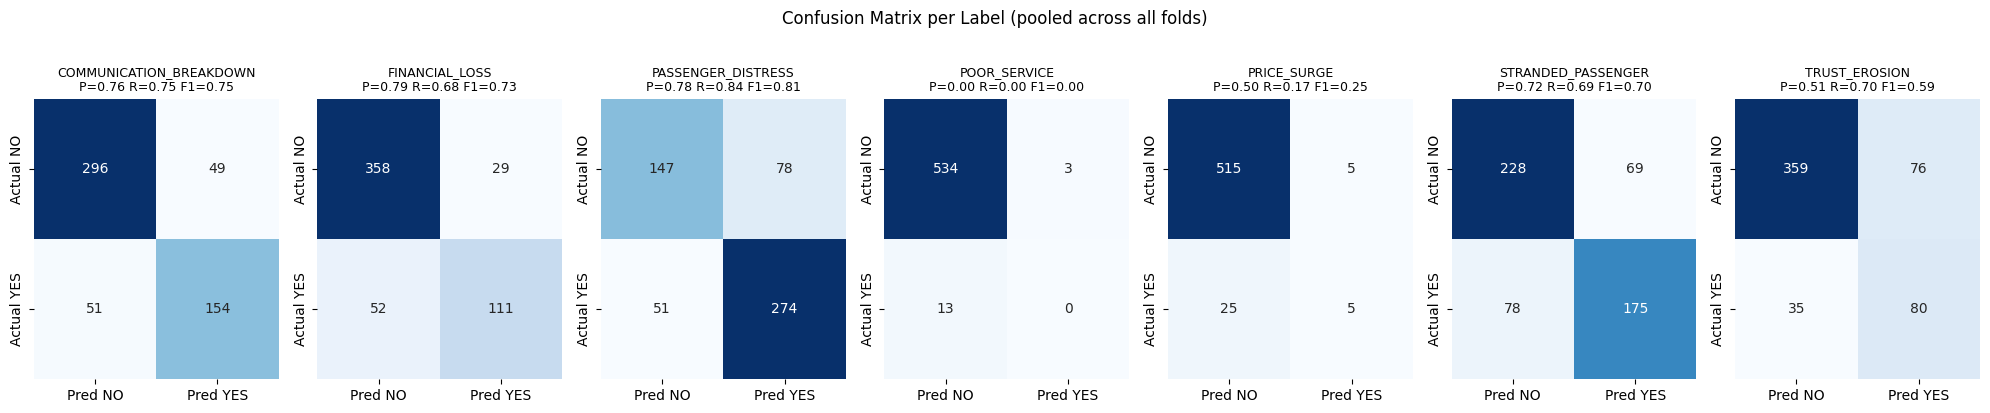

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

# ── Confusion Matrix for each label ──────────────────────────
cms = multilabel_confusion_matrix(y_true_all, y_pred_all)

fig, axes = plt.subplots(1, len(CODES), figsize=(20, 4))

for i, (code, cm) in enumerate(zip(CODES, cms)):
    tn, fp, fn, tp = cm.ravel()

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i],
        xticklabels=['Pred NO', 'Pred YES'],
        yticklabels=['Actual NO', 'Actual YES'],
        cbar=False,
    )
    precision = tp/(tp+fp) if (tp+fp) > 0 else 0
    recall    = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

    axes[i].set_title(f"{code}\nP={precision:.2f} R={recall:.2f} F1={f1:.2f}", fontsize=9)

plt.suptitle("Confusion Matrix per Label (pooled across all folds)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

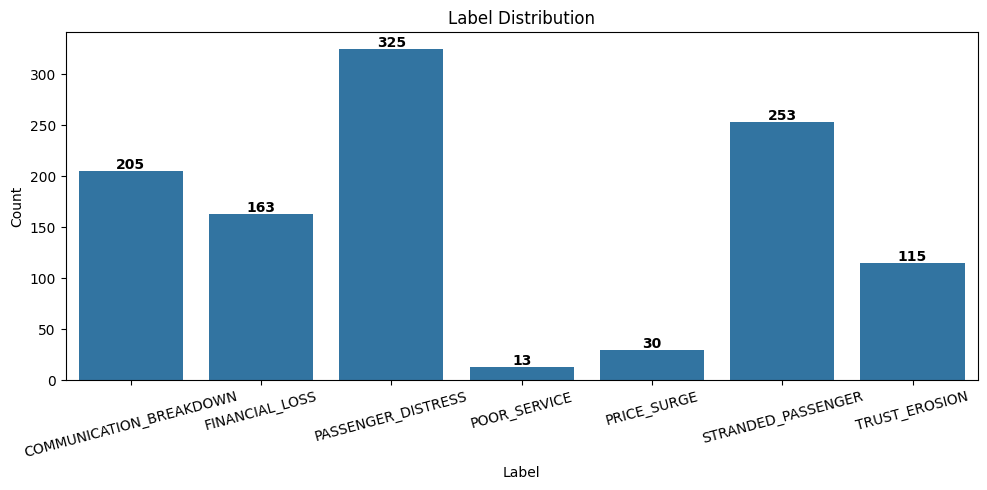

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = [y[:, i].sum() for i in range(len(CODES))]
plt.figure(figsize=(10, 5))
sns.barplot(x=CODES, y=counts)
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=15)
for i, v in enumerate(counts):
    plt.text(i, v+2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

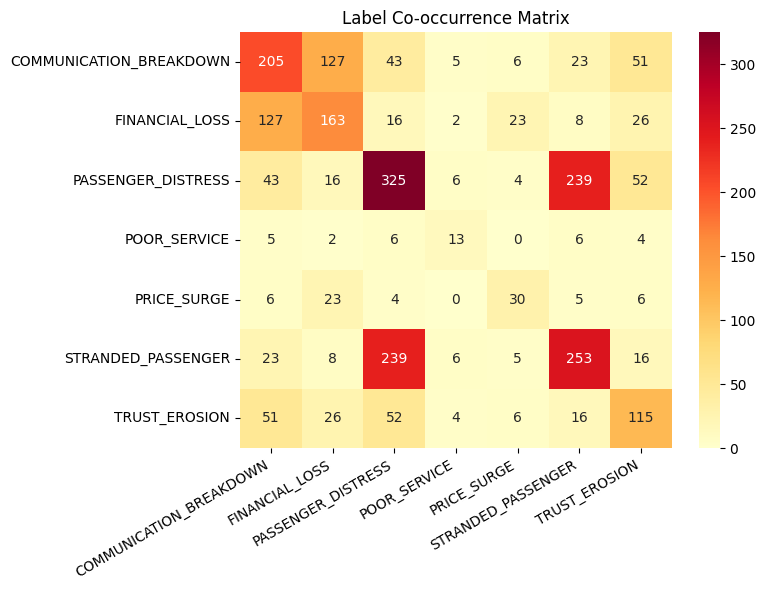

In [40]:
co_matrix = y.T @ y  # shape (n_classes, n_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(
    co_matrix,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=CODES,
    yticklabels=CODES,
)
plt.title("Label Co-occurrence Matrix")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

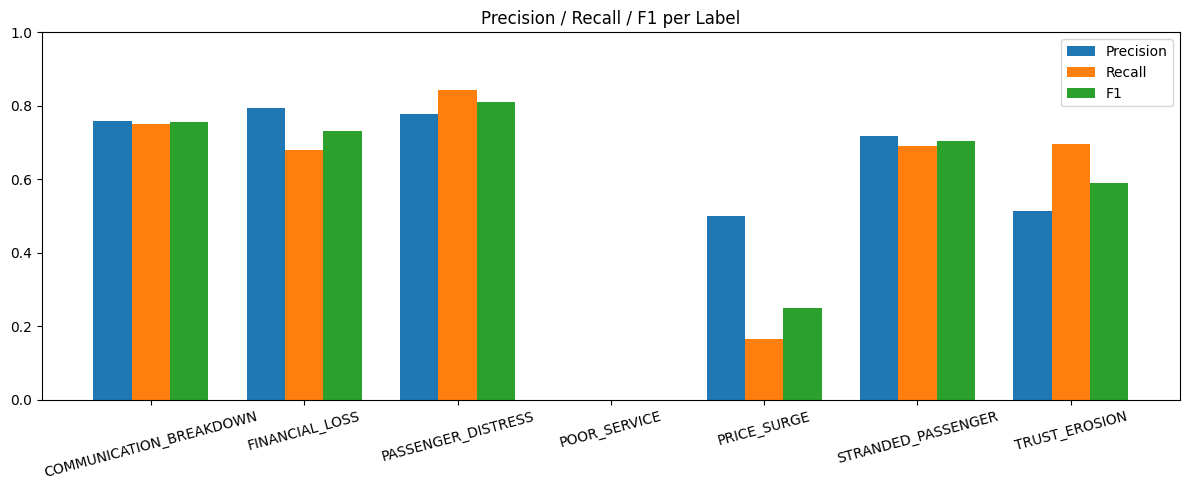

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true_all, y_pred_all, average=None, zero_division=0)
recall    = recall_score(y_true_all, y_pred_all, average=None, zero_division=0)
f1        = f1_score(y_true_all, y_pred_all, average=None, zero_division=0)

x = np.arange(len(CODES))
width = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x,         recall,    width, label='Recall')
plt.bar(x + width, f1,        width, label='F1')
plt.xticks(x, CODES, rotation=15)
plt.ylim(0, 1)
plt.title("Precision / Recall / F1 per Label")
plt.legend()
plt.tight_layout()
plt.show()

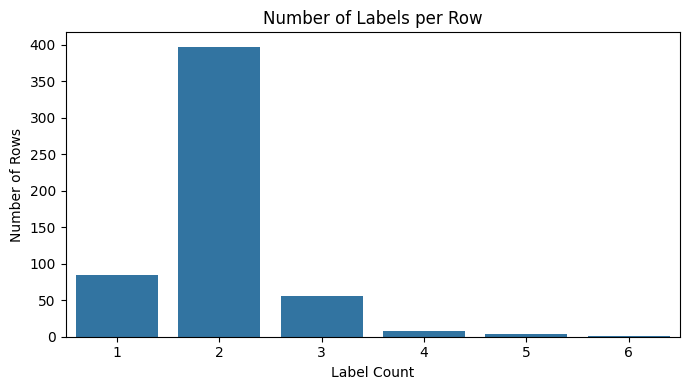

In [42]:
labels_per_row = y.sum(axis=1)
plt.figure(figsize=(7, 4))
sns.countplot(x=labels_per_row)
plt.title("Number of Labels per Row")
plt.xlabel("Label Count")
plt.ylabel("Number of Rows")
plt.tight_layout()
plt.show()

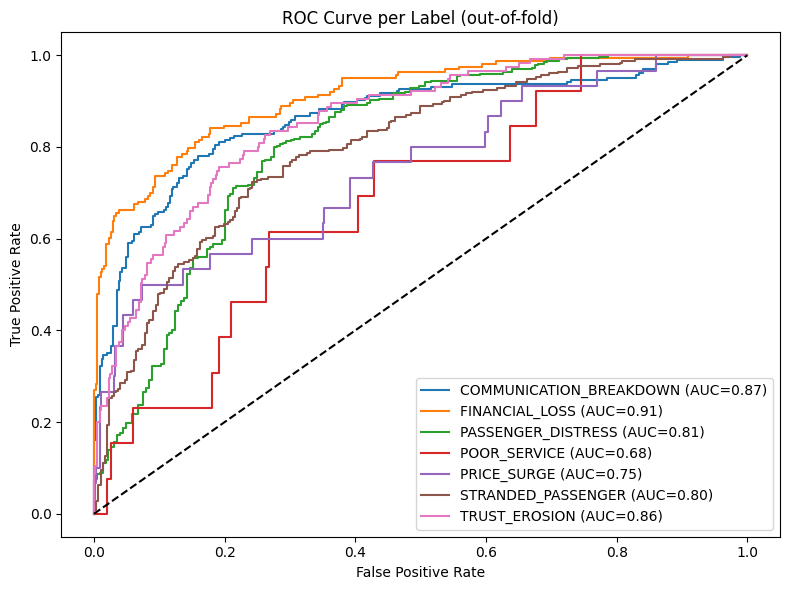

In [43]:
# ── ROC Curve per Label (out-of-fold, honest) ─────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline

def build_clf():
    return make_pipeline(
        TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True),
        OneVsRestClassifier(LogisticRegression(
            class_weight='balanced', max_iter=2000, C=1.0, solver='liblinear')))

# Out-of-fold probability predictions
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_scores = np.zeros_like(y, dtype=float)
for tr, te in kf.split(X):
    clf = build_clf()
    clf.fit(X[tr], y[tr])
    y_scores[te] = clf.predict_proba(X[te])

plt.figure(figsize=(8, 6))
for i, code in enumerate(CODES):
    # skip labels with only one class present (can't compute ROC)
    if len(np.unique(y[:, i])) < 2:
        print(f"Skipping {code}: only one class present")
        continue
    fpr, tpr, _ = roc_curve(y[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{code} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Label (out-of-fold)")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()